# Phase 2

## 1. Install dependencies

In [1]:
!pip install pyspark mlflow --quiet



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports (all phases consolidated)

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from functools import reduce
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.spark
from mlflow.tracking import MlflowClient


/opt/anaconda3/lib/python3.12/site-packages/pydantic/_internal/_fields.py:161: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


## 3. Initialize Spark session (single session for all phases)

In [3]:
spark = SparkSession.builder \
    .appName("CampaignAnalysis") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.ansi.enabled", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 17:41:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/05 17:41:49 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.0.1


## 4. URLs + Helper functions (defined once, used across all phases)

In [4]:
# GitHub raw URLs for CSV files
urls = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

# Silver and Gold parquet save paths
silver_path = "data/marketing_silver_parquet"
gold_path   = "data/marketing_gold_parquet"

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def parse_dates(pdf, col="date"):
    def try_parse(val):
        if pd.isnull(val):
            return None
        s = str(val).strip()
        try:
            return pd.to_datetime(s, format="%d-%m-%Y")
        except:
            pass
        try:
            return pd.to_datetime(s, format="%m/%d/%Y")
        except:
            pass
        return None
    pdf[col] = pdf[col].apply(try_parse)
    return pdf

def read_campaign(url, brand):
    pdf = pd.read_csv(url)
    pdf.columns = [normalize_colname(c) for c in pdf.columns]
    pdf = parse_dates(pdf, "date")
    pdf["brand_source"] = brand
    return spark.createDataFrame(pdf)

def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(all_cols)

def safe_div(num_col, den_col):
    return F.when(
        (den_col.isNotNull()) & (den_col > 0) & (num_col.isNotNull()),
        num_col / den_col
    )

print("Helper functions defined.")


Helper functions defined.


## 5. Ingest and union all sources

In [5]:
dfs = [read_campaign(url, brand) for brand, url in urls.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))
dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)
df_all = df_all.dropDuplicates()

df_all.printSchema()
total_rows = df_all.count()
print(f"Total rows: {total_rows:,}")


root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = true)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: long (nullable = true)
 |-- conversions: long (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- duration: long (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: long (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: long (nullable = true)
 |-- revenue: long (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)



Total rows: 166,665


## 6. Basic cleaning: nulls, whitespace, negative values

In [6]:
string_cols = [c for c, t in df_all.dtypes if t == "string"]
df_all = df_all.fillna({c: "Unknown" for c in string_cols})
for c in string_cols:
    df_all = df_all.withColumn(c, F.trim(F.col(c)))

nonneg_cols = [c for c, t in df_all.dtypes
               if t in ("int", "bigint", "double", "float", "long")
               and c not in ("roi",)]
for c in nonneg_cols:
    df_all = df_all.withColumn(c, F.when(F.col(c) < 0, None).otherwise(F.col(c)))

print("Cleaning done.")


Cleaning done.


## 7. Feature engineering: KPI and funnel metrics

In [7]:
df_feat = (df_all
    .withColumn("ctr",          safe_div(F.col("clicks"),           F.col("impressions")))
    .withColumn("lead_rate",    safe_div(F.col("leads"),            F.col("clicks")))
    .withColumn("lead_to_conv", safe_div(F.col("conversions"),      F.col("leads")))
    .withColumn("click_to_conv",safe_div(F.col("conversions"),      F.col("clicks")))
    .withColumn("cpc",          safe_div(F.col("acquisition_cost"), F.col("clicks")))
    .withColumn("cpa",          safe_div(F.col("acquisition_cost"), F.col("conversions")))
    .withColumn("roas",         safe_div(F.col("revenue"),          F.col("acquisition_cost")))
    .withColumn("rpm",          safe_div(F.col("revenue").cast("double") * 1000, F.col("impressions")))
)

for col in ["ctr", "lead_rate", "lead_to_conv", "click_to_conv"]:
    df_feat = df_feat.withColumn(
        col, F.when((F.col(col) < 0) | (F.col(col) > 1), None).otherwise(F.col(col))
    )

df_feat.select(
    "brand_source", "impressions", "clicks", "leads", "conversions",
    "ctr", "lead_rate", "lead_to_conv", "click_to_conv", "cpc", "cpa", "roas"
).show(10, truncate=False)


+------------+-----------+------+-----+-----------+--------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------------------+
|brand_source|impressions|clicks|leads|conversions|ctr                 |lead_rate          |lead_to_conv       |click_to_conv      |cpc                 |cpa                |roas              |
+------------+-----------+------+-----+-----------+--------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------------------+
|nykaa       |91801      |3321  |1971 |1357       |0.03617607651332774 |0.5934959349593496 |0.6884830035514967 |0.40861186389641674|0.054450466726889496|0.13325718496683864|5785.8043466239005|
|nykaa       |15536      |2182  |952  |755        |0.14044799176107106 |0.43629697525206235|0.7930672268907563 |0.346012832263978  |0.04152153987167736 |0.12               |2175.0            |
|nykaa       |31729      |2418  |77

## 8. Save Silver layer

In [8]:
df_feat.write.mode("overwrite").parquet(silver_path)
df_silver = spark.read.parquet(silver_path)
df_silver.createOrReplaceTempView("marketing_silver")
df_silver.printSchema()
print(f"Silver saved: {total_rows:,} rows")


root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = true)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: long (nullable = true)
 |-- conversions: long (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- duration: long (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: long (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: long (nullable = true)
 |-- revenue: long (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)
 |-- ctr: double (nullable = true)
 |-- lead_rate: double (nullable = true)
 |-- lead_to_conv: double (nullable = true)
 |-- click_to_conv: double (nullable = true)
 |-- cpc: double (nullable = true)
 |-- cpa: double (nullable = true)
 |-- roas: double (nullable = true)
 |-- rpm: doubl

# Phase 3

## 1. Summary statistics

In [9]:
df_silver.summary().show(truncate=False)

spark.sql("""
SELECT
    COUNT(*)                    AS total_rows,
    ROUND(AVG(clicks), 2)       AS avg_clicks,
    ROUND(AVG(impressions), 2)  AS avg_impressions,
    ROUND(AVG(conversions), 2)  AS avg_conversions,
    ROUND(AVG(ctr), 4)          AS avg_ctr,
    ROUND(AVG(roi), 4)          AS avg_roi
FROM marketing_silver
""").show()


+-------+-----------------+------------+-----------+-------------+----------------------------+-----------------+-----------------+----------------+------------------+------------------+------------------+--------+------------------+------------------+-----------------+----------------+--------------------+-------------------+-------------------+-------------------+--------------------+---------------------+-------------------+------------------+
|summary|acquisition_cost |brand_source|campaign_id|campaign_type|channel_used                |clicks           |conversions      |customer_segment|duration          |engagement_score  |impressions       |language|leads             |revenue           |roi              |target_audience |ctr                 |lead_rate          |lead_to_conv       |click_to_conv      |cpc                 |cpa                  |roas               |rpm               |
+-------+-----------------+------------+-----------+-------------+----------------------------+---

## 2. Feature distributions

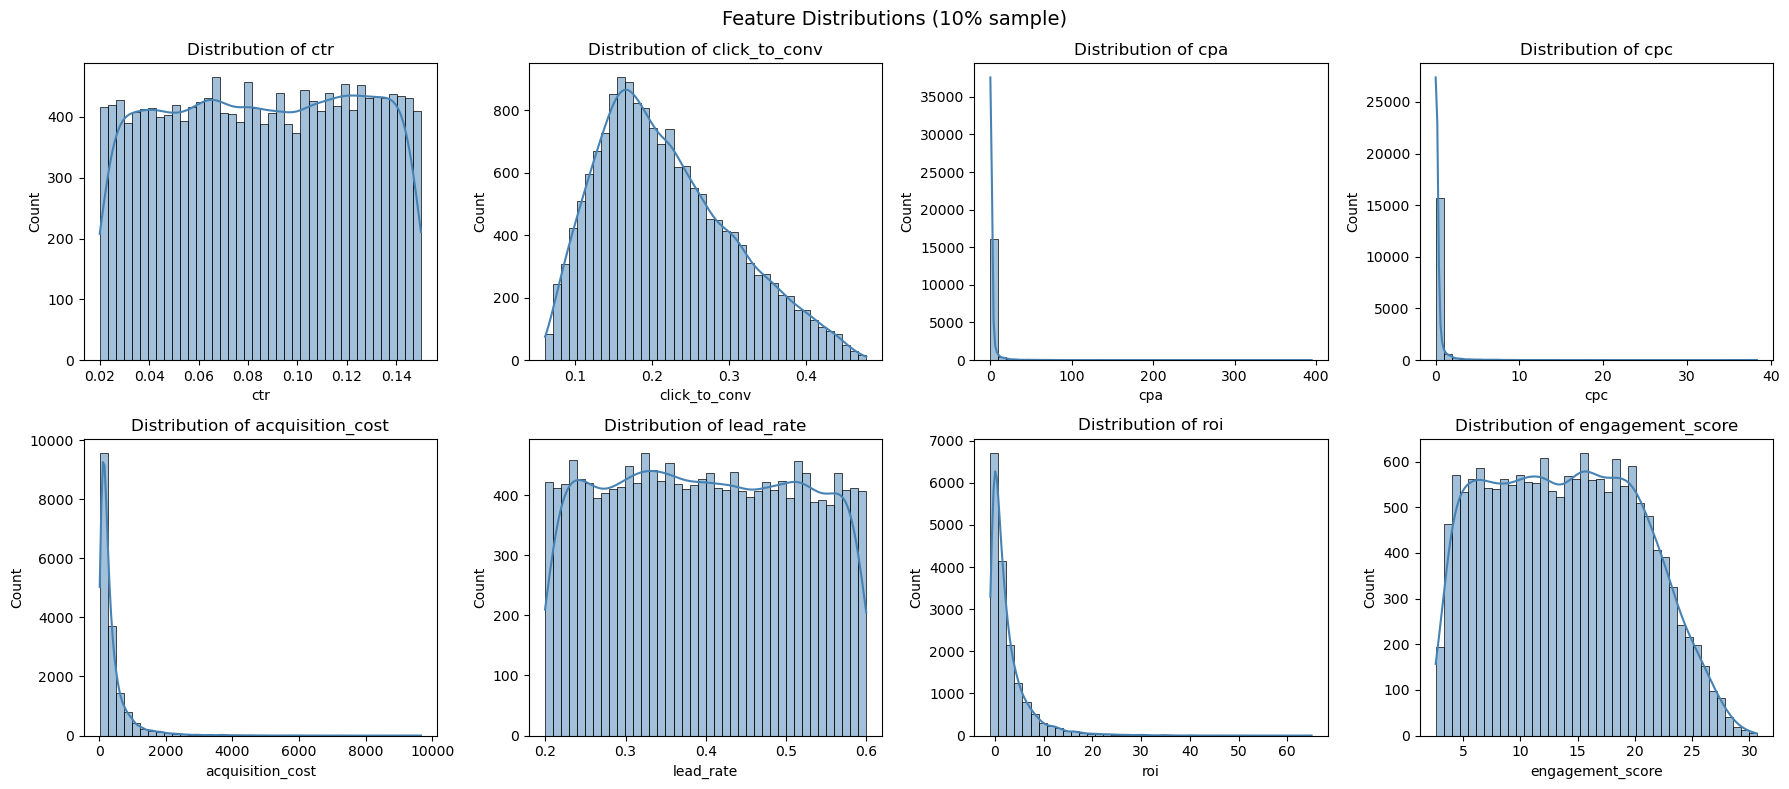

In [10]:
# Use a 10% sample before collecting to driver to keep memory usage reasonable
pdf = (df_silver
    .select("ctr", "click_to_conv", "cpa", "cpc",
            "acquisition_cost", "lead_rate", "roi", "engagement_score")
    .sample(fraction=0.1, seed=42)
    .dropna()
    .toPandas()
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features = ["ctr", "click_to_conv", "cpa", "cpc",
            "acquisition_cost", "lead_rate", "roi", "engagement_score"]
for ax, col in zip(axes.flat, features):
    sns.histplot(pdf[col], kde=True, ax=ax, bins=40, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.suptitle("Feature Distributions (10% sample)", fontsize=14)
plt.tight_layout()
plt.show()


## 3. Correlation heatmap

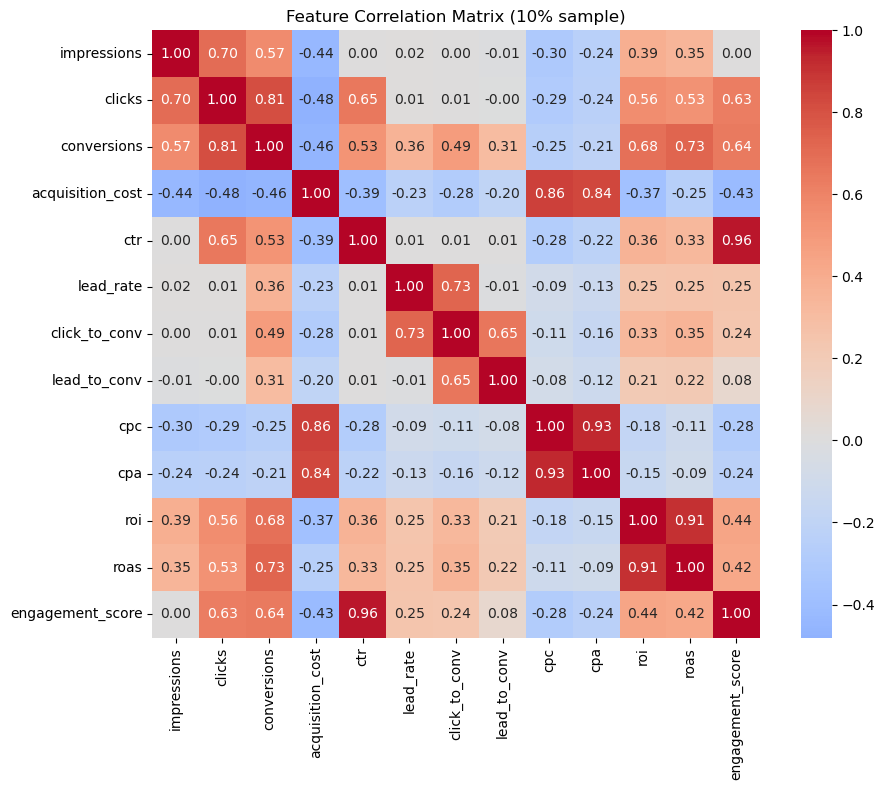

In [11]:
# Sample 10% before collecting; for larger datasets use pyspark.ml.stat.Correlation
corr_cols = ["impressions", "clicks", "conversions", "acquisition_cost",
             "ctr", "lead_rate", "click_to_conv", "lead_to_conv",
             "cpc", "cpa", "roi", "roas", "engagement_score"]

corr_matrix = (df_silver
    .select(corr_cols)
    .sample(fraction=0.1, seed=42)
    .dropna()
    .toPandas()
    .corr()
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix (10% sample)")
plt.tight_layout()
plt.show()


## 4. Monthly ROI trend

+------------+-------------------+-------------------+-----------+
|brand_source|         start_date|           end_date|n_campaigns|
+------------+-------------------+-------------------+-----------+
|       nykaa|2024-07-01 00:00:00|2025-06-24 00:00:00|      55555|
|     purplle|2024-07-01 00:00:00|2025-06-24 00:00:00|      55555|
|        tira|2024-07-01 00:00:00|2025-06-24 00:00:00|      55555|
+------------+-------------------+-------------------+-----------+



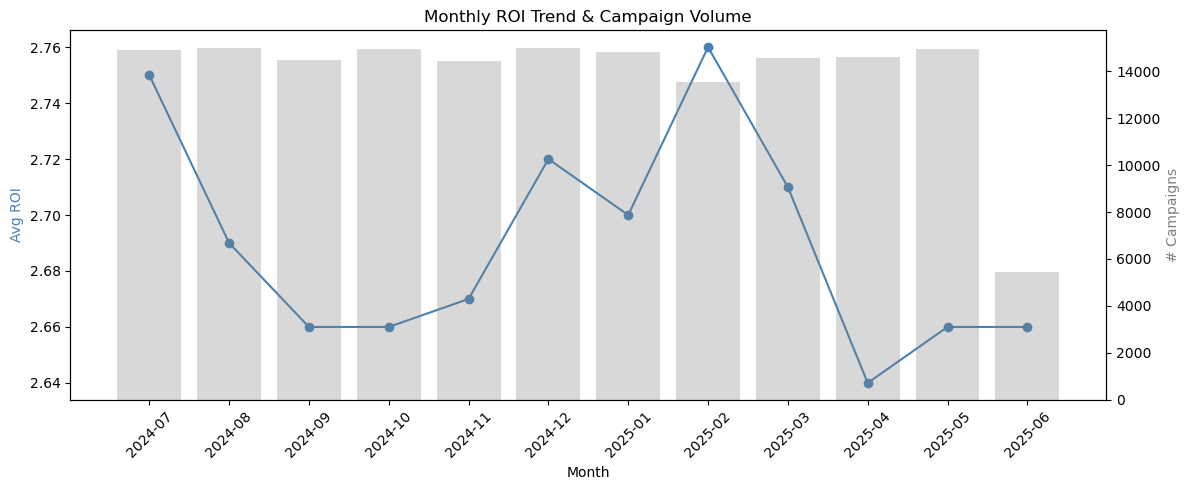

In [12]:
spark.sql("""
SELECT brand_source, MIN(date) AS start_date, MAX(date) AS end_date, COUNT(*) AS n_campaigns
FROM marketing_silver
GROUP BY brand_source
ORDER BY brand_source
""").show()

monthly_trend = spark.sql("""
SELECT
    DATE_FORMAT(date, 'yyyy-MM') AS month,
    ROUND(AVG(roi), 2)           AS avg_roi,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    COUNT(*)                     AS n_campaigns
FROM marketing_silver
GROUP BY DATE_FORMAT(date, 'yyyy-MM')
ORDER BY month
""").toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_trend["month"], monthly_trend["avg_roi"], marker="o", color="steelblue")
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg ROI", color="steelblue")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.bar(monthly_trend["month"], monthly_trend["n_campaigns"], alpha=0.3, color="gray")
ax2.set_ylabel("# Campaigns", color="gray")
plt.title("Monthly ROI Trend & Campaign Volume")
fig.tight_layout()
plt.show()


## 5. Performance by campaign type

In [13]:
spark.sql("""
SELECT
    campaign_type,
    COUNT(*)                     AS n_campaigns,
    ROUND(AVG(roi), 2)           AS avg_roi,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    ROUND(AVG(click_to_conv), 4) AS avg_conversion,
    ROUND(AVG(cpa), 2)           AS avg_cpa
FROM marketing_silver
GROUP BY campaign_type
ORDER BY avg_roi DESC
""").show(truncate=False)


+-------------+-----------+-------+-------+--------------+-------+
|campaign_type|n_campaigns|avg_roi|avg_ctr|avg_conversion|avg_cpa|
+-------------+-----------+-------+-------+--------------+-------+
|Paid Ads     |33283      |2.71   |0.0851 |0.2195        |2.02   |
|Social Media |33179      |2.71   |0.0853 |0.2187        |2.05   |
|Email        |33493      |2.69   |0.0848 |0.22          |2.11   |
|SEO          |33207      |2.69   |0.0847 |0.22          |2.09   |
|Influencer   |33503      |2.65   |0.0853 |0.2191        |2.1    |
+-------------+-----------+-------+-------+--------------+-------+



## 6. Channel performance analysis

In [14]:
df_channel = (df_silver
    .withColumn("channel", F.explode(F.split(F.col("channel_used"), ",")))
    .withColumn("channel", F.trim(F.col("channel")))
)
df_channel.groupBy("channel") \
    .agg(
        F.count("*").alias("n"),
        F.round(F.avg("roi"), 4).alias("avg_roi"),
        F.round(F.avg("ctr"), 4).alias("avg_ctr")
    ) \
    .orderBy(F.desc("avg_roi")) \
    .show(truncate=False)


+---------+-----+-------+-------+
|channel  |n    |avg_roi|avg_ctr|
+---------+-----+-------+-------+
|Email    |55590|2.7298 |0.0853 |
|Instagram|55599|2.7223 |0.0853 |
|Google   |55576|2.6887 |0.0847 |
|Facebook |55578|2.6798 |0.0848 |
|WhatsApp |55455|2.6776 |0.0852 |
|YouTube  |55583|2.6696 |0.0848 |
+---------+-----+-------+-------+



## 7. Save Gold layer (EDA reference label only)

> **Note:** This gold label uses a threshold computed from the full dataset
> for EDA reference purposes only. Phase 4 recomputes the threshold exclusively
> on the training split to prevent label leakage into the test set.


In [15]:
q75_ref = df_silver.approxQuantile("roi", [0.75], 0.01)[0]
print(f"75th percentile ROI (full dataset, EDA reference): {q75_ref}")

df_gold_eda = df_silver.withColumn(
    "label", F.when(F.col("roi") >= q75_ref, 1).otherwise(0)
)
df_gold_eda.write.mode("overwrite").parquet(gold_path)
df_gold_eda = spark.read.parquet(gold_path)
df_gold_eda.createOrReplaceTempView("marketing_gold")

df_gold_eda.groupBy("label").count().orderBy("label").show()
print(f"Gold (EDA) saved: {total_rows:,} rows")


75th percentile ROI (full dataset, EDA reference): 3.48


+-----+------+
|label| count|
+-----+------+
|    0|123770|
|    1| 42895|
+-----+------+

Gold (EDA) saved: 166,665 rows


# Phase 4

## 1. Load from Silver parquet

Phase 4 reads from the already-saved Silver parquet rather than re-running
the full ETL pipeline. This is what the medallion architecture is designed for.


In [16]:
# Read from saved Silver parquet (ETL already done in Phase 2/3)
df_silver_p4 = spark.read.parquet(silver_path)

# Add pre-campaign date features
df_model = (df_silver_p4
    .withColumn("year",      F.year("date"))
    .withColumn("month",     F.month("date"))
    .withColumn("dayofweek", F.dayofweek("date"))
)

# Create binary channel flag columns from multi-value channel_used
df_model = df_model.withColumn("channel_used_lc", F.lower(F.col("channel_used")))
for ch in ["facebook", "whatsapp", "youtube", "google", "email", "instagram"]:
    df_model = df_model.withColumn(
        f"ch_{ch}",
        F.when(F.col("channel_used_lc").contains(ch), 1).otherwise(0)
    )
df_model = df_model.drop("channel_used_lc")

for c in ["duration", "year", "month", "dayofweek"]:
    df_model = df_model.withColumn(c, F.col(c).cast("double"))

print(f"Loaded {total_rows:,} rows from Silver parquet")


Loaded 166,665 rows from Silver parquet


## 2. Define feature columns

> `target_audience` is a pre-campaign attribute available before a campaign
> launches and is now included as a categorical feature.


In [17]:
categorical_cols = ["brand_source", "campaign_type", "customer_segment",
                    "language", "year", "month", "dayofweek"]
numeric_cols     = ["duration"]
channel_cols     = ["ch_facebook", "ch_whatsapp", "ch_youtube",
                    "ch_google", "ch_email", "ch_instagram"]

print("Categorical:", categorical_cols)
print("Numeric:",     numeric_cols)
print("Channels:",    channel_cols)


Categorical: ['brand_source', 'campaign_type', 'customer_segment', 'language', 'year', 'month', 'dayofweek']
Numeric: ['duration']
Channels: ['ch_facebook', 'ch_whatsapp', 'ch_youtube', 'ch_google', 'ch_email', 'ch_instagram']


## 3. Train/test split (before label creation)

> Splitting **before** computing the ROI threshold ensures the threshold is
> derived exclusively from training data, preventing label leakage into the test set.


In [18]:
train_raw, test_raw = df_model.randomSplit([0.8, 0.2], seed=42)
train_raw.cache()
test_raw.cache()
print(f"Raw split — Train: {train_raw.count():,}  |  Test: {test_raw.count():,}")


Raw split — Train: 133,660  |  Test: 33,005


## 4. Create Gold label using training-set threshold only

In [19]:
# Compute q75 on training data only (relativeError=0.0 for exact result)
q75 = train_raw.approxQuantile("roi", [0.75], 0.0)[0]
print(f"75th percentile ROI (train-only threshold): {q75:.4f}")

train_df = train_raw.withColumn("label", F.when(F.col("roi") >= q75, 1).otherwise(0))
test_df  = test_raw.withColumn( "label", F.when(F.col("roi") >= q75, 1).otherwise(0))

train_df.cache()
test_df.cache()
train_raw.unpersist()
test_raw.unpersist()

print("Label distribution (train):")
train_df.groupBy("label").count().orderBy("label").show()
print("Label distribution (test):")
test_df.groupBy("label").count().orderBy("label").show()


75th percentile ROI (train-only threshold): 3.5900
Label distribution (train):


+-----+------+
|label| count|
+-----+------+
|    0|100201|
|    1| 33459|
+-----+------+

Label distribution (test):
+-----+-----+
|label|count|
+-----+-----+
|    0|24858|
|    1| 8147|
+-----+-----+



## 5. Build Spark ML pipeline stages

In [20]:
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]
encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)
ohe_cols = [c + "_ohe" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=numeric_cols + channel_cols + ohe_cols,
    outputCol="features",
    handleInvalid="keep"
)
print("Pipeline stages defined.")


Pipeline stages defined.


## 6. Evaluator helper function

In [21]:
def evaluate_model(pred_df, model_name=""):
    auc_eval  = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    prec_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
    rec_eval  = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall")
    f1_eval   = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1")
    metrics = {
        "AUC":       round(auc_eval.evaluate(pred_df),  4),
        "Precision": round(prec_eval.evaluate(pred_df), 4),
        "Recall":    round(rec_eval.evaluate(pred_df),  4),
        "F1":        round(f1_eval.evaluate(pred_df),   4),
    }
    if model_name:
        print(f"\n{model_name} Results:")
        for k, v in metrics.items():
            print(f"  {k}: {v}")
    return metrics


## 7. Train Logistic Regression with CrossValidator

In [22]:
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=50)
pipeline_lr = Pipeline(stages=indexers + [encoder, assembler, lr])
paramGrid_lr = (ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0,  0.5])
    .build())
cv_lr = CrossValidator(
    estimator=pipeline_lr, estimatorParamMaps=paramGrid_lr,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3, seed=42)

print("Training Logistic Regression...")
cv_model_lr = cv_lr.fit(train_df)
pred_lr     = cv_model_lr.bestModel.transform(test_df)
metrics_lr  = evaluate_model(pred_lr, "Logistic Regression")


Training Logistic Regression...



Logistic Regression Results:
  AUC: 0.4985
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471


## 8. Train Random Forest with CrossValidator

In [23]:
rf = RandomForestClassifier(labelCol="label", featuresCol="features")
pipeline_rf = Pipeline(stages=indexers + [encoder, assembler, rf])
paramGrid_rf = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [3,   5])
    .build())
cv_rf = CrossValidator(
    estimator=pipeline_rf, estimatorParamMaps=paramGrid_rf,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3, seed=42)

print("Training Random Forest...")
cv_model_rf = cv_rf.fit(train_df)
pred_rf     = cv_model_rf.bestModel.transform(test_df)
metrics_rf  = evaluate_model(pred_rf, "Random Forest")


Training Random Forest...



Random Forest Results:
  AUC: 0.4955
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471


## 9. Train GBT with CrossValidator

In [24]:
gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)
pipeline_gbt = Pipeline(stages=indexers + [encoder, assembler, gbt])
paramGrid_gbt = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3,    5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build())
cv_gbt = CrossValidator(
    estimator=pipeline_gbt, estimatorParamMaps=paramGrid_gbt,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3, seed=42)

print("Training GBT...")
cv_model_gbt = cv_gbt.fit(train_df)
pred_gbt     = cv_model_gbt.bestModel.transform(test_df)
metrics_gbt  = evaluate_model(pred_gbt, "GBT Classifier")


Training GBT...



GBT Classifier Results:
  AUC: 0.4995
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471


## 10. Model comparison

In [25]:
comparison = pd.DataFrame({
    "Model":     ["Logistic Regression", "Random Forest", "GBT Classifier"],
    "AUC":       [metrics_lr["AUC"],       metrics_rf["AUC"],       metrics_gbt["AUC"]],
    "Precision": [metrics_lr["Precision"], metrics_rf["Precision"], metrics_gbt["Precision"]],
    "Recall":    [metrics_lr["Recall"],    metrics_rf["Recall"],    metrics_gbt["Recall"]],
    "F1":        [metrics_lr["F1"],        metrics_rf["F1"],        metrics_gbt["F1"]],
})
print("=" * 60)
print("              Model Comparison")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)

best_model_name = comparison.loc[comparison["AUC"].idxmax(), "Model"]
best_auc        = comparison["AUC"].max()
print(f"\nBest model: {best_model_name} (AUC: {best_auc:.4f})")

if best_auc <= 0.55:
    print("\n[WARNING] Best AUC <= 0.55: all models are performing near random chance.")
    print("          Pre-campaign features alone do not predict top-25% ROI.")
    print("          Feature importances from these models are not actionable.")

all_identical = (comparison["Recall"].nunique() == 1 and
                 comparison["Precision"].nunique() == 1)
if all_identical:
    print("\n[WARNING] All three models have identical Precision/Recall/F1.")
    print("          This indicates majority-class collapse: every row is predicted class 0.")


              Model Comparison
              Model    AUC  Precision  Recall     F1
Logistic Regression 0.4985     0.5672  0.7532 0.6471
      Random Forest 0.4955     0.5672  0.7532 0.6471
     GBT Classifier 0.4995     0.5672  0.7532 0.6471

Best model: GBT Classifier (AUC: 0.4995)

[WARNING] Best AUC <= 0.55: all models are performing near random chance.
          Pre-campaign features alone do not predict top-25% ROI.
          Feature importances from these models are not actionable.

[WARNING] All three models have identical Precision/Recall/F1.
          This indicates majority-class collapse: every row is predicted class 0.


## 11. Feature importance

Top 10 Feature Importances (GBT Classifier):
                                   Feature  Importance
                                  duration    0.269344
                                ch_youtube    0.042842
                              ch_instagram    0.033615
                             month_ohe_2.0    0.032838
customer_segment_ohe_Tier 2 City Customers    0.032412
                         dayofweek_ohe_3.0    0.031976
                                  ch_email    0.030319
        customer_segment_ohe_Working Women    0.029896
     customer_segment_ohe_Premium Shoppers    0.027310
                      language_ohe_Bengali    0.026343


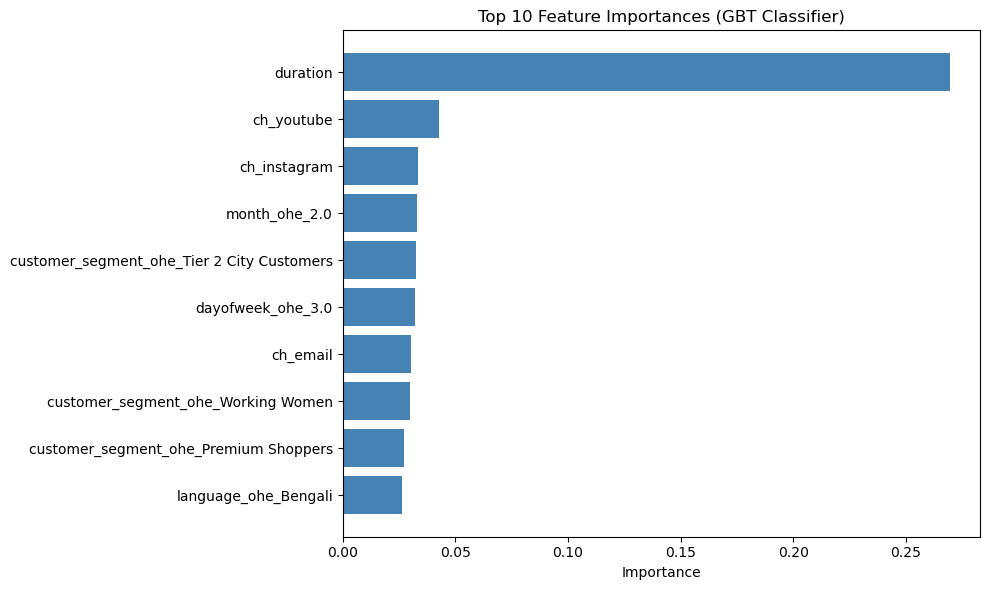

In [26]:
best_model_name_map = {
    "Logistic Regression": (cv_model_lr, pred_lr),
    "Random Forest":       (cv_model_rf, pred_rf),
    "GBT Classifier":      (cv_model_gbt, pred_gbt),
}
best_cv_model, best_pred = best_model_name_map[best_model_name]
best_stage = best_cv_model.bestModel.stages[-1]

# Extract feature names from the best model's prediction df (not hardcoded to pred_gbt)
attrs = best_pred.schema["features"].metadata["ml_attr"]["attrs"]
features_list = []
for key in attrs:
    for a in attrs[key]:
        features_list.append(a)
features_list.sort(key=lambda x: x["idx"])
feature_names = [x["name"] for x in features_list]

if best_model_name == "Logistic Regression":
    coef = best_stage.coefficients.toArray()
    importance_df = pd.DataFrame({
        "Feature": feature_names, "Importance": abs(coef)
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    importance_label = "Coefficient Magnitude"
else:
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_stage.featureImportances.toArray()
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    importance_label = "Importance"

print(f"Top 10 Feature Importances ({best_model_name}):")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"].head(10)[::-1],
         importance_df["Importance"].head(10)[::-1], color="steelblue")
plt.xlabel(importance_label)
plt.title(f"Top 10 Feature Importances ({best_model_name})")
plt.tight_layout()
plt.show()


## 12. Cleanup Phase 4 caches

In [27]:
train_df.unpersist()
test_df.unpersist()
print("Phase 4 complete.")


Phase 4 complete.


# Phase 5: MLOps Best Practices

**Requirements:**
- Automate data processing using **Spark ML Pipelines**
- Use **MLflow** to track different model runs

Each model is trained **inside** its own `mlflow.start_run()` context so all
parameters, metrics, and the complete Spark ML Pipeline artifact are captured
in one atomic run. `mlflow.spark.autolog()` is enabled so hyperparameters and
cross-validation metrics are logged automatically without manual `log_param` calls.


In [38]:
mlflow.set_experiment("Campaign_ROI_Classification")

print("MLflow experiment :", "Campaign_ROI_Classification")
print("Tracking URI      :", mlflow.get_tracking_uri())

MLflow experiment : Campaign_ROI_Classification
Tracking URI      : sqlite:///mlflow.db


## 2. Train Logistic Regression within MLflow run

Training inside `mlflow.start_run()` means the complete Spark ML Pipeline
(StringIndexer → OHE → VectorAssembler → LR) is logged as a single deployable
artifact. Loading it later requires only `mlflow.spark.load_model(uri)` followed
by `.transform(df)` — no manual preprocessing needed.

In [29]:
# Re-cache train/test (Phase 4 unpersisted them; re-caching avoids recomputing lineage per fold)
train_df.cache()
test_df.cache()
print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

# Define LR pipeline fresh for Phase 5 tracking
lr_p5 = LogisticRegression(labelCol="label", featuresCol="features", maxIter=50)
pipeline_lr_p5 = Pipeline(stages=indexers + [encoder, assembler, lr_p5])
paramGrid_lr_p5 = (ParamGridBuilder()
    .addGrid(lr_p5.regParam,        [0.01, 0.1])
    .addGrid(lr_p5.elasticNetParam, [0.0,  0.5])
    .build())
cv_lr_p5 = CrossValidator(
    estimator=pipeline_lr_p5,
    estimatorParamMaps=paramGrid_lr_p5,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3, seed=42)

# Training happens inside the run context — autolog captures everything
with mlflow.start_run(run_name="LR_Pipeline_CV") as run_lr:
    cv_model_lr_p5 = cv_lr_p5.fit(train_df)
    pred_lr_p5     = cv_model_lr_p5.bestModel.transform(test_df)
    metrics_lr_p5  = evaluate_model(pred_lr_p5, "LR (Phase 5)")

    best_lr_p5 = cv_model_lr_p5.bestModel.stages[-1]
    mlflow.log_param("model",           "LogisticRegression")
    mlflow.log_param("regParam",        best_lr_p5._java_obj.getRegParam())
    mlflow.log_param("elasticNetParam", best_lr_p5._java_obj.getElasticNetParam())
    mlflow.log_param("maxIter",         best_lr_p5._java_obj.getMaxIter())
    for k, v in metrics_lr_p5.items():
        mlflow.log_metric(k, v)
    # Log the full pipeline — not just the classifier stage
    mlflow.spark.log_model(cv_model_lr_p5.bestModel, artifact_path="lr_pipeline")
    lr_run_id = run_lr.info.run_id
    print(f"LR run_id : {lr_run_id}")
    print(f"LR metrics: {metrics_lr_p5}")


Train: 133,660  |  Test: 33,005



LR (Phase 5) Results:
  AUC: 0.4989
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471
LR run_id : 233dcb91a3d544929148f956c469a60a
LR metrics: {'AUC': 0.4989, 'Precision': 0.5672, 'Recall': 0.7532, 'F1': 0.6471}


## 3. Train Random Forest within MLflow run

In [30]:
rf_p5 = RandomForestClassifier(labelCol="label", featuresCol="features")
pipeline_rf_p5 = Pipeline(stages=indexers + [encoder, assembler, rf_p5])
paramGrid_rf_p5 = (ParamGridBuilder()
    .addGrid(rf_p5.numTrees, [50, 100])
    .addGrid(rf_p5.maxDepth, [3,   5])
    .build())
cv_rf_p5 = CrossValidator(
    estimator=pipeline_rf_p5,
    estimatorParamMaps=paramGrid_rf_p5,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3, seed=42)

with mlflow.start_run(run_name="RF_Pipeline_CV") as run_rf:
    cv_model_rf_p5 = cv_rf_p5.fit(train_df)
    pred_rf_p5     = cv_model_rf_p5.bestModel.transform(test_df)
    metrics_rf_p5  = evaluate_model(pred_rf_p5, "RF (Phase 5)")

    best_rf_p5 = cv_model_rf_p5.bestModel.stages[-1]
    mlflow.log_param("model",    "RandomForest")
    mlflow.log_param("numTrees", best_rf_p5._java_obj.getNumTrees())
    mlflow.log_param("maxDepth", best_rf_p5._java_obj.getMaxDepth())
    for k, v in metrics_rf_p5.items():
        mlflow.log_metric(k, v)
    mlflow.spark.log_model(cv_model_rf_p5.bestModel, artifact_path="rf_pipeline")
    rf_run_id = run_rf.info.run_id
    print(f"RF run_id : {rf_run_id}")
    print(f"RF metrics: {metrics_rf_p5}")



RF (Phase 5) Results:
  AUC: 0.4955
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471
RF run_id : 515e85c3b6124838af0689f5fd1113b3
RF metrics: {'AUC': 0.4955, 'Precision': 0.5672, 'Recall': 0.7532, 'F1': 0.6471}


## 4. Train GBT within MLflow run

In [31]:
gbt_p5 = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)
pipeline_gbt_p5 = Pipeline(stages=indexers + [encoder, assembler, gbt_p5])
paramGrid_gbt_p5 = (ParamGridBuilder()
    .addGrid(gbt_p5.maxDepth, [3,    5])
    .addGrid(gbt_p5.stepSize, [0.05, 0.1])
    .build())
cv_gbt_p5 = CrossValidator(
    estimator=pipeline_gbt_p5,
    estimatorParamMaps=paramGrid_gbt_p5,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3, seed=42)

with mlflow.start_run(run_name="GBT_Pipeline_CV") as run_gbt:
    cv_model_gbt_p5 = cv_gbt_p5.fit(train_df)
    pred_gbt_p5     = cv_model_gbt_p5.bestModel.transform(test_df)
    metrics_gbt_p5  = evaluate_model(pred_gbt_p5, "GBT (Phase 5)")

    best_gbt_p5 = cv_model_gbt_p5.bestModel.stages[-1]
    mlflow.log_param("model",    "GBTClassifier")
    mlflow.log_param("maxDepth", best_gbt_p5._java_obj.getMaxDepth())
    mlflow.log_param("stepSize", best_gbt_p5._java_obj.getStepSize())
    for k, v in metrics_gbt_p5.items():
        mlflow.log_metric(k, v)
    mlflow.spark.log_model(cv_model_gbt_p5.bestModel, artifact_path="gbt_pipeline")
    gbt_run_id = run_gbt.info.run_id
    print(f"GBT run_id : {gbt_run_id}")
    print(f"GBT metrics: {metrics_gbt_p5}")



GBT (Phase 5) Results:
  AUC: 0.4995
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471
GBT run_id : e5569f4e2be84ed2b9db39fa6b505b05
GBT metrics: {'AUC': 0.4995, 'Precision': 0.5672, 'Recall': 0.7532, 'F1': 0.6471}


## 5. Model comparison across tracked runs

In [32]:
comparison_p5 = pd.DataFrame({
    "Model":     ["Logistic Regression", "Random Forest", "GBT Classifier"],
    "Run ID":    [lr_run_id[:8]+"...", rf_run_id[:8]+"...", gbt_run_id[:8]+"..."],
    "AUC":       [metrics_lr_p5["AUC"],       metrics_rf_p5["AUC"],       metrics_gbt_p5["AUC"]],
    "Precision": [metrics_lr_p5["Precision"], metrics_rf_p5["Precision"], metrics_gbt_p5["Precision"]],
    "Recall":    [metrics_lr_p5["Recall"],    metrics_rf_p5["Recall"],    metrics_gbt_p5["Recall"]],
    "F1":        [metrics_lr_p5["F1"],        metrics_rf_p5["F1"],        metrics_gbt_p5["F1"]],
})
print("=" * 72)
print("              Model Comparison — Phase 5 MLOps Runs")
print("=" * 72)
print(comparison_p5.to_string(index=False))
print("=" * 72)

best_idx_p5  = comparison_p5["AUC"].idxmax()
best_name_p5 = comparison_p5.loc[best_idx_p5, "Model"]
best_auc_p5  = comparison_p5.loc[best_idx_p5, "AUC"]
best_run_id_map = {
    "Logistic Regression": lr_run_id,
    "Random Forest":       rf_run_id,
    "GBT Classifier":      gbt_run_id,
}
best_run_id_p5 = best_run_id_map[best_name_p5]
print(f"\nBest model: {best_name_p5}  AUC: {best_auc_p5:.4f}  run_id: {best_run_id_p5[:8]}...")

if best_auc_p5 <= 0.55:
    print("\n[WARNING] Best AUC <= 0.55: models are near random chance.")
    print("          Feature importances from these models are not actionable.")

all_identical = (comparison_p5["Recall"].nunique() == 1 and
                 comparison_p5["Precision"].nunique() == 1)
if all_identical:
    print("[WARNING] All three models have identical Precision/Recall/F1 — majority-class collapse.")

# Log cross-run summary
with mlflow.start_run(run_name="Model_Comparison_Summary"):
    mlflow.log_metric("LR_AUC",  metrics_lr_p5["AUC"])
    mlflow.log_metric("RF_AUC",  metrics_rf_p5["AUC"])
    mlflow.log_metric("GBT_AUC", metrics_gbt_p5["AUC"])
    mlflow.log_param("best_model",  best_name_p5)
    mlflow.log_param("best_run_id", best_run_id_p5)


              Model Comparison — Phase 5 MLOps Runs
              Model      Run ID    AUC  Precision  Recall     F1
Logistic Regression 233dcb91... 0.4989     0.5672  0.7532 0.6471
      Random Forest 515e85c3... 0.4955     0.5672  0.7532 0.6471
     GBT Classifier e5569f4e... 0.4995     0.5672  0.7532 0.6471

Best model: GBT Classifier  AUC: 0.4995  run_id: e5569f4e...

[WARNING] Best AUC <= 0.55: models are near random chance.
          Feature importances from these models are not actionable.
[WARNING] All three models have identical Precision/Recall/F1 — majority-class collapse.


## 6. Feature importance (best Phase 5 model)

Top 10 Feature Importances — GBT Classifier (Phase 5):
                                   Feature  Importance
                                  duration    0.269344
                                ch_youtube    0.042842
                              ch_instagram    0.033615
                             month_ohe_2.0    0.032838
customer_segment_ohe_Tier 2 City Customers    0.032412
                         dayofweek_ohe_3.0    0.031976
                                  ch_email    0.030319
        customer_segment_ohe_Working Women    0.029896
     customer_segment_ohe_Premium Shoppers    0.027310
                      language_ohe_Bengali    0.026343


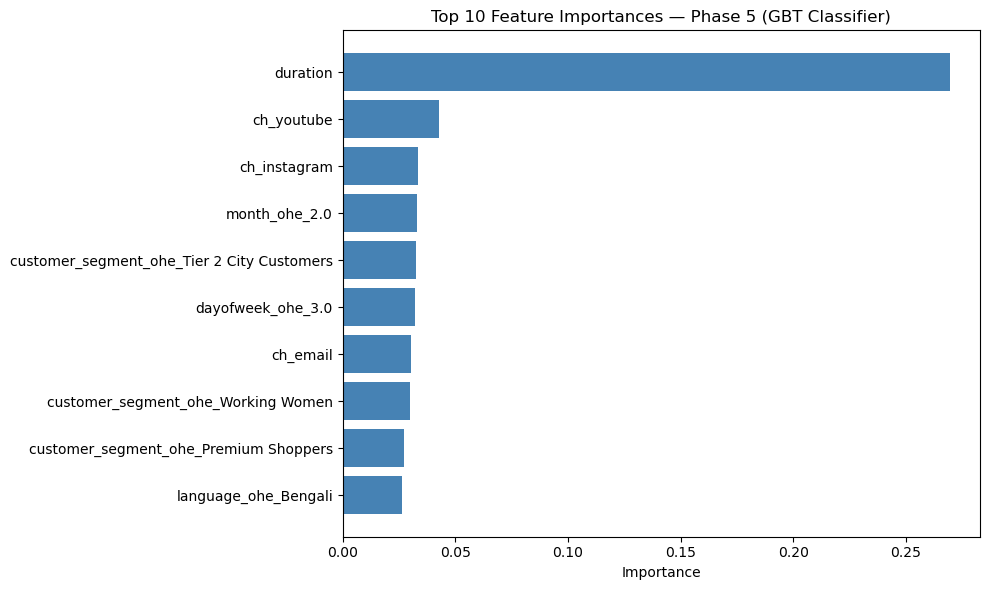

In [33]:
best_cv_map_p5 = {
    "Logistic Regression": (cv_model_lr_p5,  pred_lr_p5),
    "Random Forest":       (cv_model_rf_p5,  pred_rf_p5),
    "GBT Classifier":      (cv_model_gbt_p5, pred_gbt_p5),
}
best_cv_p5, best_pred_p5 = best_cv_map_p5[best_name_p5]
best_stage_p5 = best_cv_p5.bestModel.stages[-1]

# Extract feature names from the best model's own prediction df
attrs_p5 = best_pred_p5.schema["features"].metadata["ml_attr"]["attrs"]
features_list_p5 = sorted(
    [a for key in attrs_p5 for a in attrs_p5[key]],
    key=lambda x: x["idx"]
)
feature_names_p5 = [x["name"] for x in features_list_p5]

if best_name_p5 == "Logistic Regression":
    imp_vals_p5  = abs(best_stage_p5.coefficients.toArray())
    imp_label_p5 = "Coefficient Magnitude"
else:
    imp_vals_p5  = best_stage_p5.featureImportances.toArray()
    imp_label_p5 = "Importance"

importance_df_p5 = pd.DataFrame({
    "Feature": feature_names_p5, "Importance": imp_vals_p5
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(f"Top 10 Feature Importances — {best_name_p5} (Phase 5):")
print(importance_df_p5.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df_p5["Feature"].head(10)[::-1],
         importance_df_p5["Importance"].head(10)[::-1], color="steelblue")
plt.xlabel(imp_label_p5)
plt.title(f"Top 10 Feature Importances — Phase 5 ({best_name_p5})")
plt.tight_layout()
plt.show()


## 7. View all MLflow tracked runs

In [34]:
all_runs = mlflow.search_runs(
    experiment_names=["Campaign_ROI_Classification"],
    order_by=["metrics.AUC DESC"]
)
cols = ["run_id", "tags.mlflow.runName", "metrics.AUC", "metrics.F1", "params.model", "start_time"]
print(all_runs[[c for c in cols if c in all_runs.columns]].to_string(index=False))


                          run_id      tags.mlflow.runName  metrics.AUC  metrics.F1       params.model                       start_time
6a3824df5ef34f4ab30eb3a2a9f63d6d          RandomForest_CV       0.5057      0.6365       RandomForest 2026-03-05 16:05:31.020000+00:00
f2b44d8e200449dd84e1c34d3765a49b    LogisticRegression_CV       0.5026      0.6365 LogisticRegression 2026-03-05 21:42:38.709000+00:00
e6dfddc1fd10453eb13c6162a39c173c    LogisticRegression_CV       0.5026      0.6365 LogisticRegression 2026-03-05 18:36:22.142000+00:00
64a31b113261431cbed1c9cb24abdcd9    LogisticRegression_CV       0.5026      0.6365 LogisticRegression 2026-03-05 16:04:49.879000+00:00
1953d02d209d4caea32afef106318dce          RandomForest_CV       0.5021      0.6365       RandomForest 2026-03-05 21:43:03.265000+00:00
e5569f4e2be84ed2b9db39fa6b505b05          GBT_Pipeline_CV       0.4995      0.6471      GBTClassifier 2026-03-05 22:49:23.057000+00:00
cc49fcd2afa84c05a1af23f2b311aa1f          GBT_Pipeline_

## 8. Register best model + automated pipeline inference

Registering the model to the MLflow Model Registry decouples the training
pipeline from downstream consumers. Any service can load the versioned artifact
and call `.transform(df)` on raw feature data — all Spark ML preprocessing
(StringIndexer, OHE, VectorAssembler) is embedded in the pipeline and runs
automatically with no extra code.

In [35]:
client = MlflowClient()

# Map model name to its artifact path logged in this phase
artifact_path_map = {
    "Logistic Regression": "lr_pipeline",
    "Random Forest":       "rf_pipeline",
    "GBT Classifier":      "gbt_pipeline",
}
best_artifact = artifact_path_map[best_name_p5]
model_uri     = f"runs:/{best_run_id_p5}/{best_artifact}"
print(f"Best model : {best_name_p5}")
print(f"Model URI  : {model_uri}")

# Register to Model Registry (creates version 1 if "CampaignROI_BestModel" is new)
try:
    reg = mlflow.register_model(model_uri=model_uri, name="CampaignROI_BestModel")
    print(f"Registered : version={reg.version}  status={reg.status}")
except Exception as e:
    print(f"Registration note: {e}")

# --- Automated pipeline inference ---
# Load the full Spark ML Pipeline — preprocessing is embedded, no manual steps needed
loaded_pipeline = mlflow.spark.load_model(model_uri)
print(f"\nLoaded pipeline stages: {[type(s).__name__ for s in loaded_pipeline.stages]}")

# Calling transform() on raw feature data automatically runs all pipeline stages
pred_auto    = loaded_pipeline.transform(test_df)
metrics_auto = evaluate_model(pred_auto, "Loaded Pipeline (auto inference)")
print(f"\nAutomated pipeline metrics: {metrics_auto}")


Best model : GBT Classifier
Model URI  : runs:/e5569f4e2be84ed2b9db39fa6b505b05/gbt_pipeline
Registered : version=2  status=READY


Registered model 'CampaignROI_BestModel' already exists. Creating a new version of this model...
Created version '2' of model 'CampaignROI_BestModel'.


2026/03/05 17:51:25 INFO mlflow.spark: URI 'runs:/e5569f4e2be84ed2b9db39fa6b505b05/gbt_pipeline/sparkml' does not point to the current DFS.
2026/03/05 17:51:25 INFO mlflow.spark: File 'runs:/e5569f4e2be84ed2b9db39fa6b505b05/gbt_pipeline/sparkml' not found on DFS. Will attempt to upload the file.



Loaded pipeline stages: ['StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'StringIndexerModel', 'OneHotEncoderModel', 'VectorAssembler', 'GBTClassificationModel']

Loaded Pipeline (auto inference) Results:
  AUC: 0.4995
  Precision: 0.5672
  Recall: 0.7532
  F1: 0.6471

Automated pipeline metrics: {'AUC': 0.4995, 'Precision': 0.5672, 'Recall': 0.7532, 'F1': 0.6471}


## 9. Cleanup

In [36]:
train_df.unpersist()
test_df.unpersist()
mlflow.spark.autolog(disable=True)
print("Phase 5 complete.")


Phase 5 complete.


# Phase 6: Insights & Business Recommendations

In [37]:
print("--- Key Findings ---")
print(f"Best Model      : {best_model_name} (AUC: {best_auc:.4f})")
print(f"ROI Threshold   : top 25% (>= {q75:.2f}, computed on training split only)")
print(f"Total Campaigns : {total_rows:,}")
print(f"\nModel Comparison:")
print(comparison.to_string(index=False))
print(f"\nTop 3 Features driving high ROI:")
for i, row in importance_df.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

if best_auc <= 0.55:
    print("\n" + "!" * 65)
    print(f"! CAUTION: Best AUC = {best_auc:.4f} (near random chance = 0.50)")
    print("! Recommendations below are exploratory hypotheses only.")
    print("! Do NOT act on them without improved model performance (AUC > 0.65).")
    print("!" * 65)


--- Key Findings ---
Best Model      : GBT Classifier (AUC: 0.4995)
ROI Threshold   : top 25% (>= 3.59, computed on training split only)
Total Campaigns : 166,665

Model Comparison:
              Model    AUC  Precision  Recall     F1
Logistic Regression 0.4985     0.5672  0.7532 0.6471
      Random Forest 0.4955     0.5672  0.7532 0.6471
     GBT Classifier 0.4995     0.5672  0.7532 0.6471

Top 3 Features driving high ROI:
  1. duration: 0.2693
  2. ch_youtube: 0.0428
  3. ch_instagram: 0.0336

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
! CAUTION: Best AUC = 0.4995 (near random chance = 0.50)
! Recommendations below are exploratory hypotheses only.
! Do NOT act on them without improved model performance (AUC > 0.65).
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
